In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from numba import cuda

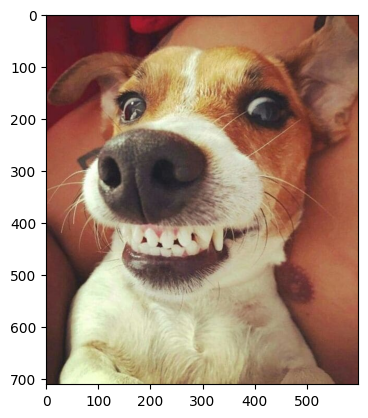

In [16]:
img = plt.imread("/content/dog.jpg")

plt.imshow(img)

In [7]:
height, width, channels = img.shape
pixelCount = height*width

flatSrc = img.reshape(pixelCount, 3)

In [10]:
start = time.time()
gray_cpu = np.zeros(pixelCount, dtype=np.uint8)

for i in range(pixelCount):

    r = flatSrc[i, 0]
    g = flatSrc[i, 1]
    b = flatSrc[i, 2]

    gray_cpu[i] = (int(r)+int(g)+int(b))//3

end = time.time()
cpu_time = end - start
print(f"CPU time: {cpu_time}, seconds")

CPU time: 0.4769740104675293 seconds


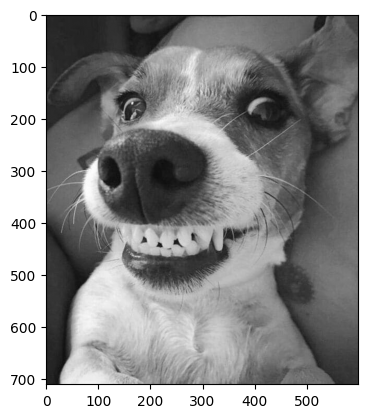

In [18]:
gc_image = gray_cpu.reshape(height, width)

plt.imshow(gc_image, cmap="gray")
plt.imsave("/content/gc.png", gc_image, cmap="gray")

In [32]:
devSrc = cuda.to_device(flatSrc)
devDst = cuda.device_array((pixelCount, 3), dtype=np.uint8)

In [34]:
blockSize = 64
gridSize = (pixelCount+blockSize-1) // blockSize

In [35]:
@cuda.jit
def grayscale(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

In [36]:
start = time.time()

grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()
end = time.time()

gpu_time = end - start
print(f"GPU time: {gpu_time} seconds")

GPU time: 0.0911872386932373 seconds


In [40]:
gray_gpu = devDst.copy_to_host()

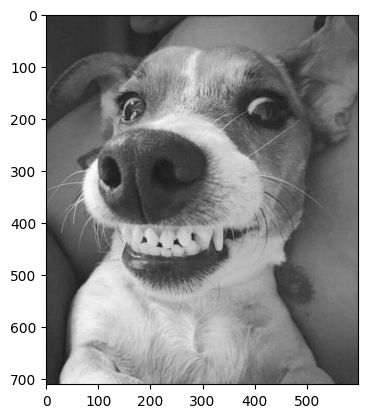

In [44]:
gp_image = gray_gpu.reshape(height, width, 3)

plt.imshow(gp_image, cmap="gray")
plt.imsave("/content/gp.png", gp_image, cmap="gray")

In [45]:
speedup = cpu_time / gpu_time

print(f"Speedup: {speedup}")

Speedup: 5.230710100479257


In [50]:
block_sizes = [32, 64, 128, 256, 512]
gpu_times = []

for blockSize in block_sizes:
    gridSize = (pixelCount+blockSize-1) // blockSize
    devDst = cuda.device_array((pixelCount, 3), dtype=np.uint8)

    start = time.time()

    grayscale[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()

    end = time.time()

    gpu_time = end - start
    gpu_times.append(gpu_time)

    print(f"Block size: {blockSize}")
    print(f"Grid size: {gridSize}")
    print(f"GPU time: {gpu_time} seconds")
    print()

Block size: 32
Grid size: 13313
GPU time: 0.0003135204315185547 seconds

Block size: 64
Grid size: 6657
GPU time: 0.0002472400665283203 seconds

Block size: 128
Grid size: 3329
GPU time: 0.0002307891845703125 seconds

Block size: 256
Grid size: 1665
GPU time: 0.0010519027709960938 seconds

Block size: 512
Grid size: 833
GPU time: 0.0002562999725341797 seconds



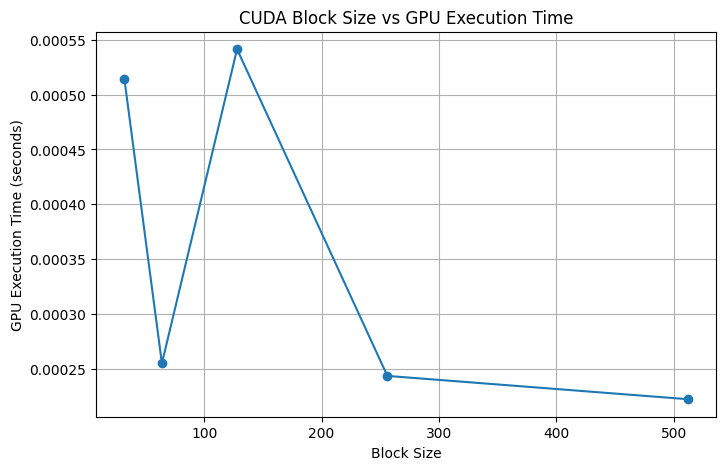

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(block_sizes, gpu_times, marker='o')

plt.xlabel("Block Size")
plt.ylabel("Time (seconds)")
plt.title("CUDA Block Size vs GPU Execution Time")

plt.grid(True)
plt.show()